In [85]:
import pandas as pd
import matplotlib.pyplot as plt
import os

C:\Users\Vandanu\AppData\Local\Temp\ipykernel_7820\2721027667.py:4: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_hv = pd.read_csv(hv_path,
C:\Users\Vandanu\AppData\Local\Temp\ipykernel_7820\2721027667.py:11: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_model = pd.read_csv(model_path,


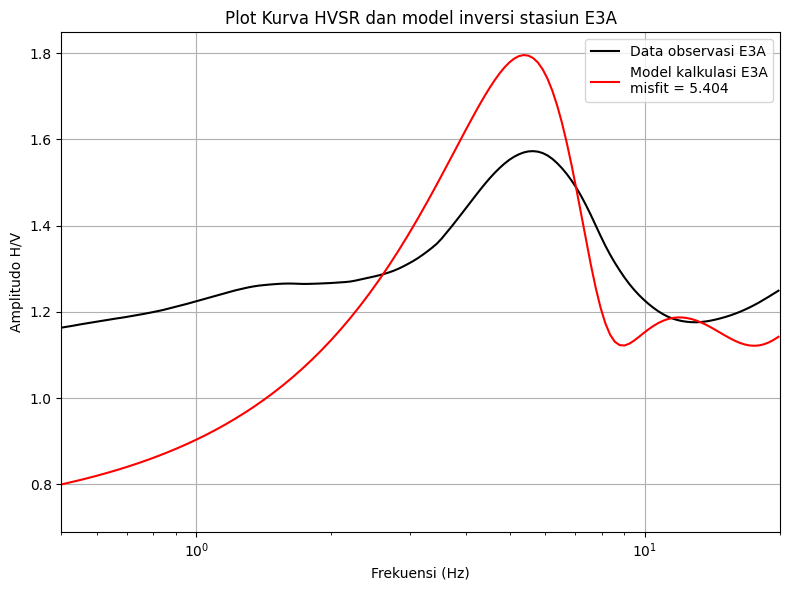

In [87]:

hv_path = 'D:/Kulon Progo 2025/Seismik Pasif/processing/2_HVSR/HV/E3A.hv'
hv_name = os.path.splitext(os.path.basename(hv_path))[0]

df_hv = pd.read_csv(hv_path, 
                 delim_whitespace=True, 
                 skiprows=9, 
                 names=['Frequency', 'Average', 'Min', 'Max'])

model_path = 'D:/Kulon Progo 2025/Seismik Pasif/processing/4_inversi/Report/ellipticity_E3A.dat'
model_name = os.path.splitext(os.path.basename(model_path))[0]
df_model = pd.read_csv(model_path, 
                 delim_whitespace=True, 
                 skiprows=4, 
                 names=['Frequency', 'Period'])

misfit = []
with open(model_path, 'r') as f:
    for line in f:
        if 'Layered model' in line and 'value=' in line:
            try:
                misfit = float(line.strip().split('value=')[-1])
            except ValueError:
                pass
            break

plt.figure(figsize=(8, 6))
plt.plot(df_hv['Frequency'], df_hv['Average'], label=f'Data observasi {hv_name}', color='black')
plt.plot(df_model['Frequency'], df_model['Period'].abs(), label=f'Model kalkulasi {hv_name}\nmisfit = {misfit:.3f}', color='red')
# plt.fill_between(df['Frequency'], df['Min'], df['Max'], color='lightblue', alpha=0.5, label='Min-Max Range')

plt.xlabel('Frekuensi (Hz)')
plt.ylabel('Amplitudo H/V')
plt.title(f'Plot Kurva HVSR dan model inversi stasiun {hv_name}')
plt.legend()
plt.grid(True)
plt.xscale('log')
plt.xlim(0.5, 20)
plt.tight_layout()
plt.show()